# Model 1: Semantic + Acoustic Features → PHQ-8 / PCL-C Scores

**Goal:** Predict clinical symptom severity from linguistic and acoustic features extracted from DAIC interview transcripts/audio.

**Inputs:**
- 11 semantic/linguistic features (cognitive distortions, affect, social language)
- 94 acoustic features (F0, MFCCs, jitter, shimmer, HNR, pause patterns, etc.)

**Targets:**
- `PHQ8_total` — depression severity score (0–24, regression + binary classification)
- `PCL_total` — PTSD symptom severity score (17–85, regression + binary classification)

**Dataset:** E-DAIC — 155 participants (train/dev split provided)

**Models:** Ridge Regression, Random Forest, Gradient Boosting (regression); Logistic Regression, Random Forest (classification)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn.linear_model import Lasso, LassoCV, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    classification_report, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

SEED = 42
np.random.seed(SEED)

## 1. Load and Merge Data

In [2]:
feats  = pd.read_csv('daic_features_v4.csv')
labels = pd.read_csv('data/edaic/labels/detailed_labels.csv')

# Merge on participant ID
df = feats.merge(labels, left_on='patient_id', right_on='Participant', how='inner')

# Compute total scores from item sums
PHQ_ITEMS = ['PHQ8_1_NoInterest','PHQ8_2_Depressed','PHQ8_3_Sleep','PHQ8_4_Tired',
             'PHQ8_5_Appetite','PHQ8_6_Failure','PHQ8_7_Concentration','PHQ8_8_Psychomotor']
PCL_ITEMS = [c for c in labels.columns if c.startswith('PCL-C_')]

df['PHQ8_total'] = df[PHQ_ITEMS].sum(axis=1)   # 0–24
df['PCL_total']  = df[PCL_ITEMS].sum(axis=1)   # 17–85

# Binary labels (standard clinical cutoffs)
# PHQ-8 >= 10 = moderate/severe depression
# PCL-C >= 44 = probable PTSD (civilian version)
df['Depression_binary'] = (df['PHQ8_total'] >= 10).astype(int)
df['PTSD_binary']       = (df['PCL_total']  >= 44).astype(int)

print(f'Dataset: {len(df)} participants')
print(f'Splits: {df["split"].value_counts().to_dict()}')
print()
print('PHQ8_total:', df['PHQ8_total'].describe().round(2).to_dict())
print('PCL_total: ', df['PCL_total'].describe().round(2).to_dict())
print()
print(f'Depression (PHQ>=10): {df["Depression_binary"].sum()} / {len(df)}')
print(f'PTSD (PCL>=44):       {df["PTSD_binary"].sum()} / {len(df)}')

Dataset: 155 participants
Splits: {'train': 116, 'dev': 39}

PHQ8_total: {'count': 155.0, 'mean': 6.62, 'std': 5.88, 'min': 0.0, '25%': 2.0, '50%': 5.0, '75%': 10.0, 'max': 23.0}
PCL_total:  {'count': 155.0, 'mean': 34.65, 'std': 16.36, 'min': 17.0, '25%': 21.0, '50%': 28.0, '75%': 46.0, 'max': 85.0}

Depression (PHQ>=10): 44 / 155
PTSD (PCL>=44):       45 / 155


In [3]:
# Define feature groups
SEMANTIC_COLS = [c for c in feats.columns if 'patient_mean' in c]
ACOUSTIC_COLS = [c for c in feats.columns if c not in SEMANTIC_COLS and c != 'patient_id']
ALL_COLS      = SEMANTIC_COLS + ACOUSTIC_COLS

print(f'Semantic features:  {len(SEMANTIC_COLS)}')
print(f'Acoustic features:  {len(ACOUSTIC_COLS)}')
print(f'Total features:     {len(ALL_COLS)}')
print(f'NaN in features:    {df[ALL_COLS].isnull().sum().sum()}')

Semantic features:  11
Acoustic features:  94
Total features:     105
NaN in features:    0


## 2. Exploratory Analysis

## 3. Cross-Validation Setup

We use the official **train/dev split** from E-DAIC for a single train-test evaluation,  
plus 5-fold cross-validation within the training set for hyperparameter selection.

In [4]:
train_df = df[df['split'] == 'train'].copy()
dev_df   = df[df['split'] == 'dev'].copy()

X_train = train_df[ALL_COLS].values
X_dev   = dev_df[ALL_COLS].values

# Regression targets
y_phq_train = train_df['PHQ8_total'].values
y_pcl_train = train_df['PCL_total'].values
y_phq_dev   = dev_df['PHQ8_total'].values
y_pcl_dev   = dev_df['PCL_total'].values

# Binary classification targets
y_dep_train = train_df['Depression_binary'].values
y_ptsd_train = train_df['PTSD_binary'].values
y_dep_dev   = dev_df['Depression_binary'].values
y_ptsd_dev  = dev_df['PTSD_binary'].values

print(f'Train: {len(train_df)} | Dev: {len(dev_df)}')
print(f'Train depressed: {y_dep_train.sum()} / {len(y_dep_train)}')
print(f'Train PTSD:      {y_ptsd_train.sum()} / {len(y_ptsd_train)}')
print(f'Dev depressed:   {y_dep_dev.sum()} / {len(y_dep_dev)}')
print(f'Dev PTSD:        {y_ptsd_dev.sum()} / {len(y_ptsd_dev)}')

cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

Train: 116 | Dev: 39
Train depressed: 33 / 116
Train PTSD:      33 / 116
Dev depressed:   11 / 39
Dev PTSD:        12 / 39


## 4. Regression: Predict PHQ-8 and PCL-C Scores

**Models tried:** LassoCV, ElasticNetCV, RF/GBM/SVR on Lasso-selected features, on three feature subsets (All / Semantic / Acoustic).

**Best models (from grid search):**
- **PHQ-8 → LassoCV on all features** (R²=0.167, 21/105 features selected)
- **PCL-C → ElasticNetCV on semantic features only** (R²=0.207, acoustic features hurt this target)

Acoustic features add noise for PCL-C because PTSD severity is driven by *what* a person says (trauma language, avoidance) — not *how* they say it.

In [5]:
from sklearn.linear_model import ElasticNetCV

# Pre-process: scale once for all models
preproc_all = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
preproc_sem = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

X_train_all = preproc_all.fit_transform(train_df[ALL_COLS].values)
X_dev_all   = preproc_all.transform(dev_df[ALL_COLS].values)
X_train_sem = preproc_sem.fit_transform(train_df[SEMANTIC_COLS].values)
X_dev_sem   = preproc_sem.transform(dev_df[SEMANTIC_COLS].values)

# Keep preproc alias for downstream cells
preproc = preproc_all


def fit_eval(model, X_tr, y_tr, X_dv, y_dv, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_dv)
    r2   = r2_score(y_dv, y_pred)
    mae  = mean_absolute_error(y_dv, y_pred)
    rmse = np.sqrt(mean_squared_error(y_dv, y_pred))
    extra = ''
    if hasattr(model, 'alpha_'):   extra += f'  α={model.alpha_:.4f}'
    if hasattr(model, 'l1_ratio_'): extra += f'  l1={model.l1_ratio_:.2f}'
    if hasattr(model, 'coef_'):    extra += f'  nz={np.sum(model.coef_!=0)}'
    print(f'  {label}: R²={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}{extra}')
    imp = model.coef_ if hasattr(model, 'coef_') else (
          model.feature_importances_ if hasattr(model, 'feature_importances_') else None)
    return {'model': label, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'y_pred': y_pred, 'importance': imp}


reg_results = {}
print('── PHQ-8 (best: LassoCV, all features) ──')
reg_results['PHQ-8'] = {}

lasso_phq = LassoCV(cv=5, max_iter=10000, random_state=SEED)
reg_results['PHQ-8']['LassoCV (all)'] = fit_eval(lasso_phq, X_train_all, y_phq_train, X_dev_all, y_phq_dev, 'LassoCV (all feats)')

enet_phq = ElasticNetCV(cv=5, max_iter=10000, random_state=SEED, l1_ratio=[.1,.5,.7,.9,.95,1])
reg_results['PHQ-8']['ElasticNet (all)'] = fit_eval(enet_phq, X_train_all, y_phq_train, X_dev_all, y_phq_dev, 'ElasticNet (all feats)')

lasso_phq_sem = LassoCV(cv=5, max_iter=10000, random_state=SEED)
reg_results['PHQ-8']['LassoCV (semantic)'] = fit_eval(lasso_phq_sem, X_train_sem, y_phq_train, X_dev_sem, y_phq_dev, 'LassoCV (semantic only)')

print()
print('── PCL-C (best: ElasticNetCV, semantic features only) ──')
reg_results['PCL-C'] = {}

enet_pcl = ElasticNetCV(cv=5, max_iter=10000, random_state=SEED, l1_ratio=[.1,.5,.7,.9,.95,1])
reg_results['PCL-C']['ElasticNet (semantic)'] = fit_eval(enet_pcl, X_train_sem, y_pcl_train, X_dev_sem, y_pcl_dev, 'ElasticNet (semantic only)')

lasso_pcl = LassoCV(cv=5, max_iter=10000, random_state=SEED)
reg_results['PCL-C']['LassoCV (semantic)'] = fit_eval(lasso_pcl, X_train_sem, y_pcl_train, X_dev_sem, y_pcl_dev, 'LassoCV (semantic only)')

lasso_pcl_all = LassoCV(cv=5, max_iter=10000, random_state=SEED)
reg_results['PCL-C']['LassoCV (all)'] = fit_eval(lasso_pcl_all, X_train_all, y_pcl_train, X_dev_all, y_pcl_dev, 'LassoCV (all feats)')

── PHQ-8 (best: LassoCV, all features) ──
  LassoCV (all feats): R²=0.167  MAE=3.80  RMSE=4.99  α=0.3737  nz=21
  ElasticNet (all feats): R²=0.167  MAE=3.80  RMSE=4.99  α=0.3737  l1=1.00  nz=21
  LassoCV (semantic only): R²=0.148  MAE=3.89  RMSE=5.05  α=0.2139  nz=6

── PCL-C (best: ElasticNetCV, semantic features only) ──
  ElasticNet (semantic only): R²=0.207  MAE=11.54  RMSE=13.83  α=0.0745  l1=0.50  nz=11
  LassoCV (semantic only): R²=0.168  MAE=11.79  RMSE=14.17  α=0.1505  nz=11
  LassoCV (all feats): R²=-0.270  MAE=14.38  RMSE=17.51  α=0.3241  nz=45


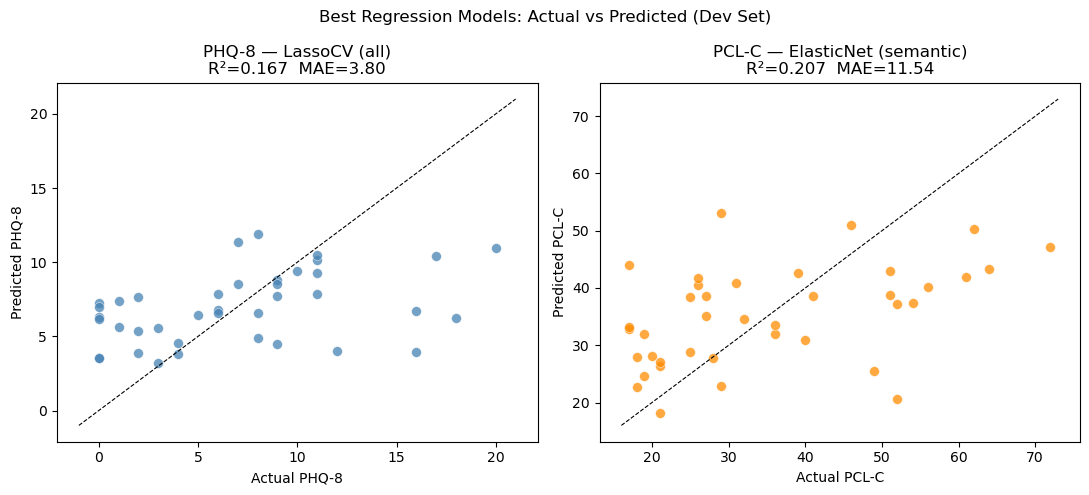

In [6]:
# Scatter: Actual vs Predicted — best model per target
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (target, best_key, y_dv, color) in zip(axes, [
    ('PHQ-8', 'LassoCV (all)',         y_phq_dev, 'steelblue'),
    ('PCL-C', 'ElasticNet (semantic)', y_pcl_dev, 'darkorange'),
]):
    r    = reg_results[target][best_key]
    y_pred = r['y_pred']
    mn   = min(y_dv.min(), y_pred.min()) - 1
    mx   = max(y_dv.max(), y_pred.max()) + 1
    ax.scatter(y_dv, y_pred, alpha=0.75, color=color, s=50, edgecolors='white', linewidths=0.4)
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8)
    ax.set_xlabel(f'Actual {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target} — {best_key}\nR²={r["R2"]:.3f}  MAE={r["MAE"]:.2f}')

plt.suptitle('Best Regression Models: Actual vs Predicted (Dev Set)', fontsize=12)
plt.tight_layout()
plt.savefig('regression_scatter.png', dpi=150)
plt.show()

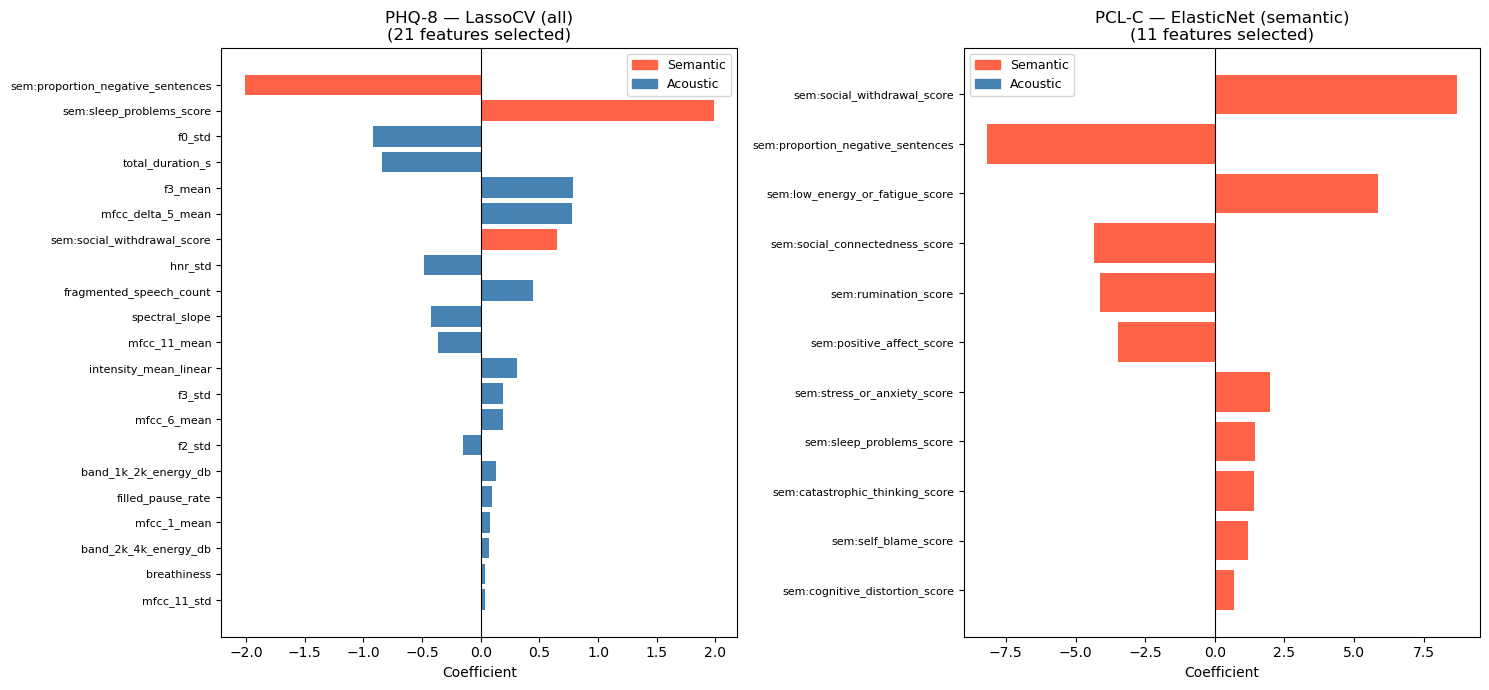

In [7]:
# Selected features and their coefficients for best models
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, (target, best_key, feat_cols) in zip(axes, [
    ('PHQ-8', 'LassoCV (all)',         ALL_COLS),
    ('PCL-C', 'ElasticNet (semantic)', SEMANTIC_COLS),
]):
    coef = reg_results[target][best_key]['importance']
    nonzero = coef != 0
    names  = [feat_cols[i] for i in range(len(feat_cols)) if nonzero[i]]
    vals   = coef[nonzero]
    order  = np.argsort(np.abs(vals))
    names, vals = [names[i] for i in order], vals[order]

    bar_colors = ['tomato' if n in SEMANTIC_COLS else 'steelblue' for n in names]
    ax.barh(range(len(names)), vals, color=bar_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(
        [n.replace('patient_mean_avg_','sem:').replace('patient_mean_','sem:') for n in names],
        fontsize=8
    )
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{target} — {best_key}\n({len(names)} features selected)')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='tomato', label='Semantic'), Patch(color='steelblue', label='Acoustic')],
              fontsize=9)

plt.tight_layout()
plt.savefig('lasso_selected_features.png', dpi=150)
plt.show()

## 5. Classification: Depression and PTSD Binary Labels

PHQ-8 ≥ 10 → depressed; PCL-C ≥ 44 → probable PTSD.

In [8]:
def eval_classifier(model, X_train, y_train, X_dev, y_dev, label, feature_names):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_dev)
    y_prob = pipe.predict_proba(X_dev)[:, 1] if hasattr(pipe, 'predict_proba') else None

    f1  = f1_score(y_dev, y_pred, average='weighted')
    acc = np.mean(y_dev == y_pred)
    auc = roc_auc_score(y_dev, pipe.predict_proba(X_dev)[:, 1]) if hasattr(pipe.named_steps['clf'], 'predict_proba') else np.nan

    print(f'  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')
    print(classification_report(y_dev, y_pred, target_names=['Negative', 'Positive']))

    return {'target': label, 'model': type(model).__name__,
            'accuracy': acc, 'f1_weighted': f1, 'auc': auc, 'y_pred': y_pred}


clf_models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)),
    ('RandomForest',       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)),
    ('DecisionTree',       DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED)),
]

clf_results = []
for target_name, y_tr, y_dv in [('Depression (PHQ>=10)', y_dep_train, y_dep_dev),
                                   ('PTSD (PCL>=44)',       y_ptsd_train, y_ptsd_dev)]:
    print(f'\n── {target_name} ──')
    for mname, model in clf_models:
        print(f'  {mname}:')
        r = eval_classifier(model, X_train, y_tr, X_dev, y_dv, target_name, ALL_COLS)
        r['model'] = mname
        clf_results.append(r)


── Depression (PHQ>=10) ──
  LogisticRegression:
  Acc=0.641  F1=0.659  AUC=0.705
              precision    recall  f1-score   support

    Negative       0.85      0.61      0.71        28
    Positive       0.42      0.73      0.53        11

    accuracy                           0.64        39
   macro avg       0.64      0.67      0.62        39
weighted avg       0.73      0.64      0.66        39

  RandomForest:
  Acc=0.744  F1=0.656  AUC=0.643
              precision    recall  f1-score   support

    Negative       0.74      1.00      0.85        28
    Positive       1.00      0.09      0.17        11

    accuracy                           0.74        39
   macro avg       0.87      0.55      0.51        39
weighted avg       0.81      0.74      0.66        39

  DecisionTree:
  Acc=0.538  F1=0.556  AUC=0.515
              precision    recall  f1-score   support

    Negative       0.71      0.61      0.65        28
    Positive       0.27      0.36      0.31        11

 

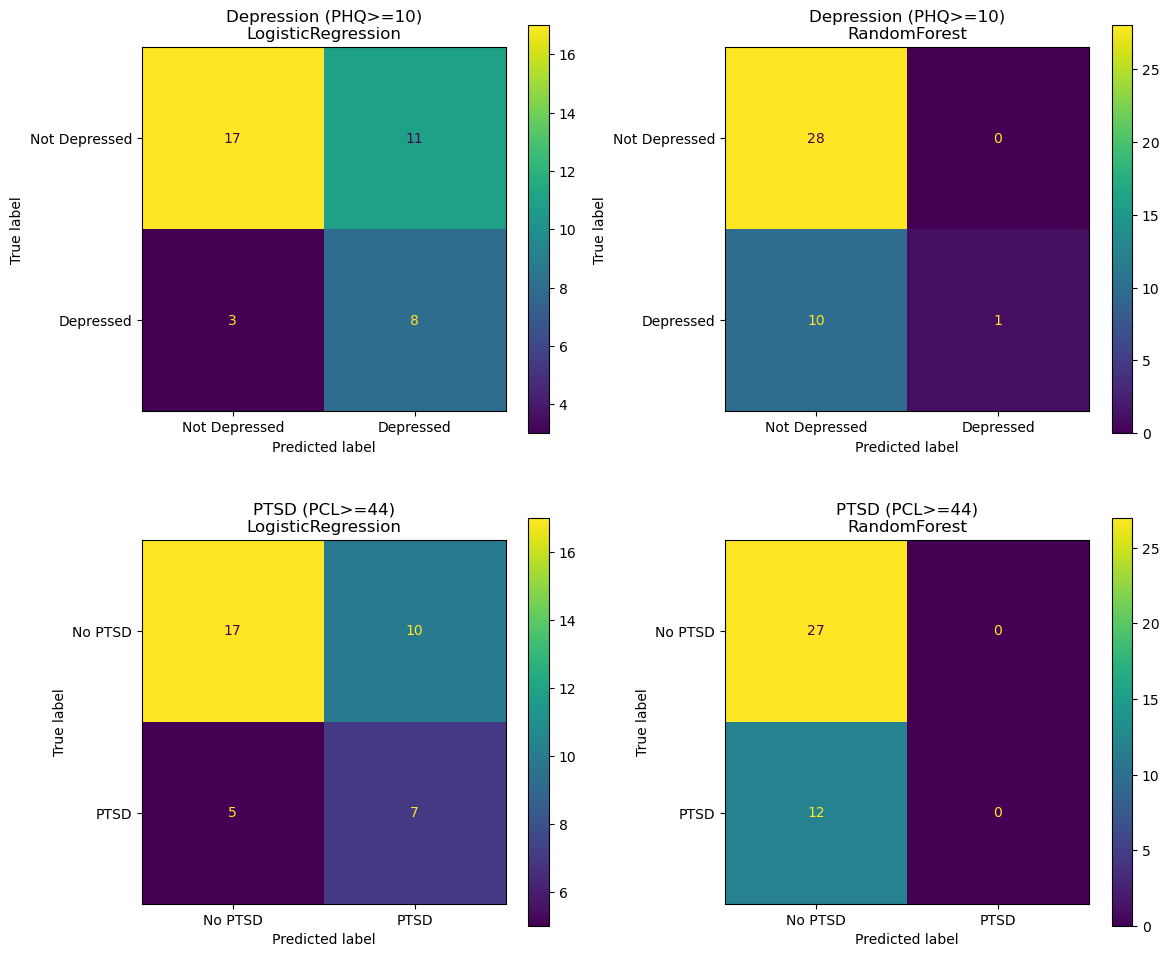

In [9]:
# Confusion matrices for best classifier
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (target_name, y_tr, y_dv, class_names) in enumerate([
    ('Depression (PHQ>=10)', y_dep_train, y_dep_dev, ['Not Depressed', 'Depressed']),
    ('PTSD (PCL>=44)', y_ptsd_train, y_ptsd_dev, ['No PTSD', 'PTSD']),
]):
    for col, (mname, model) in enumerate([
        ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)),
        ('RandomForest',       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)),
    ]):
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('clf',     model)
        ])
        pipe.fit(X_train, y_tr)
        y_pred = pipe.predict(X_dev)
        ConfusionMatrixDisplay.from_predictions(
            y_dv, y_pred, display_labels=class_names, ax=axes[row, col]
        )
        axes[row, col].set_title(f'{target_name}\n{mname}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 6. Feature Group Ablation

Compare using semantic features only vs. acoustic features only vs. both combined.

Ablation Study (best model per target):
target            features        model     R2   MAE  n_features
 PHQ-8       Semantic only      LassoCV  0.148  3.89           6
 PHQ-8       Acoustic only      LassoCV -0.008  4.50           0
 PHQ-8 Semantic + Acoustic      LassoCV  0.167  3.80          21
 PCL-C       Semantic only ElasticNetCV  0.207 11.54          11
 PCL-C       Acoustic only ElasticNetCV -0.003 13.36           1
 PCL-C Semantic + Acoustic ElasticNetCV -0.270 14.38          45


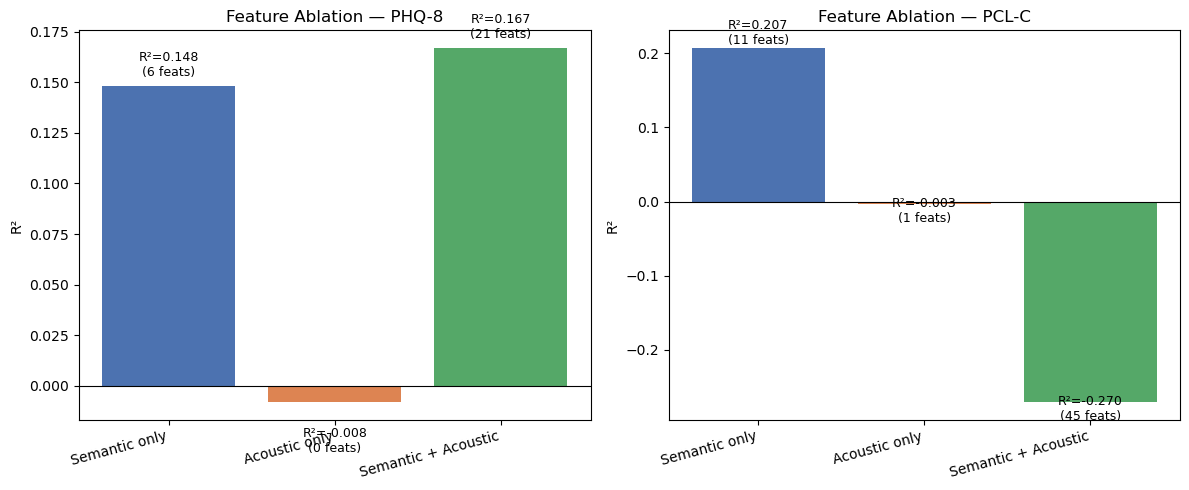

In [10]:
ablation_results = []

configs = [
    ('PHQ-8', [('Semantic only', SEMANTIC_COLS, preproc_sem),
               ('Acoustic only', ACOUSTIC_COLS, None),
               ('Semantic + Acoustic', ALL_COLS, preproc_all)],
     y_phq_train, y_phq_dev, LassoCV),
    ('PCL-C', [('Semantic only', SEMANTIC_COLS, preproc_sem),
               ('Acoustic only', ACOUSTIC_COLS, None),
               ('Semantic + Acoustic', ALL_COLS, preproc_all)],
     y_pcl_train, y_pcl_dev, ElasticNetCV),
]

for target, feat_sets, y_tr, y_dv, ModelClass in configs:
    for feat_name, cols, pp in feat_sets:
        if pp is None:
            pp = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
        X_tr = pp.fit_transform(train_df[cols].values)
        X_dv = pp.transform(dev_df[cols].values)
        kw = dict(cv=5, max_iter=10000, random_state=SEED)
        if ModelClass == ElasticNetCV:
            kw['l1_ratio'] = [.1,.5,.7,.9,.95,1]
        m = ModelClass(**kw).fit(X_tr, y_tr)
        y_pred = m.predict(X_dv)
        nz = int(np.sum(m.coef_ != 0))
        ablation_results.append({
            'target': target, 'features': feat_name,
            'model': ModelClass.__name__,
            'R2':  round(r2_score(y_dv, y_pred), 3),
            'MAE': round(mean_absolute_error(y_dv, y_pred), 2),
            'n_features': nz,
        })

ablation_df = pd.DataFrame(ablation_results)
print('Ablation Study (best model per target):')
print(ablation_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = ['#4C72B0', '#DD8452', '#55A868']
for ax, target in zip(axes, ['PHQ-8', 'PCL-C']):
    sub = ablation_df[ablation_df['target'] == target].reset_index(drop=True)
    bars = ax.bar(sub['features'], sub['R2'], color=palette)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('R²')
    ax.set_title(f'Feature Ablation — {target}')
    for bar, (_, row) in zip(bars, sub.iterrows()):
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                y + (0.005 if y >= 0 else -0.025),
                f"R²={row['R2']:.3f}\n({row['n_features']} feats)",
                ha='center', fontsize=9)
    ax.set_xticklabels(sub['features'], rotation=15, ha='right')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

## 7. Export Model 1 Outputs for Model 3

Export predicted PHQ-8 and PCL-C scores (regression) and depression/PTSD probabilities (classification) for all participants, for use in the final ensemble aggregator.

In [11]:
from sklearn.linear_model import ElasticNetCV

# Scale all participants for prediction
X_all_all = preproc_all.transform(df[ALL_COLS].values)
X_all_sem = preproc_sem.transform(df[SEMANTIC_COLS].values)

# PHQ-8: LassoCV on all features (trained on train split)
final_lasso_phq = LassoCV(cv=5, max_iter=10000, random_state=SEED).fit(X_train_all, y_phq_train)
phq_pred_all = final_lasso_phq.predict(X_all_all)

# PCL-C: ElasticNetCV on semantic features only
final_enet_pcl = ElasticNetCV(cv=5, max_iter=10000, random_state=SEED,
                               l1_ratio=[.1,.5,.7,.9,.95,1]).fit(X_train_sem, y_pcl_train)
pcl_pred_all = final_enet_pcl.predict(X_all_sem)

# Classification probabilities (for Model 3 stacking)
clf_dep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()),
                    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED))])
clf_dep.fit(train_df[ALL_COLS].values, y_dep_train)
dep_prob_all = clf_dep.predict_proba(df[ALL_COLS].values)[:, 1]

clf_ptsd = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()),
                     ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED))])
clf_ptsd.fit(train_df[SEMANTIC_COLS].values, y_ptsd_train)
ptsd_prob_all = clf_ptsd.predict_proba(df[SEMANTIC_COLS].values)[:, 1]

model1_output = pd.DataFrame({
    'patient_id':       df['patient_id'].values,
    'split':            df['split'].values,
    'PHQ8_true':        df['PHQ8_total'].values,
    'PCL_true':         df['PCL_total'].values,
    'PHQ8_pred':        phq_pred_all.round(2),
    'PCL_pred':         pcl_pred_all.round(2),
    'depression_prob':  dep_prob_all.round(4),
    'ptsd_prob':        ptsd_prob_all.round(4),
    'depression_score': (phq_pred_all.clip(0, 24) / 24).round(4),
    'ptsd_score':       ((pcl_pred_all.clip(17, 85) - 17) / (85 - 17)).round(4),
})

out_path = 'data/edaic/labels/model1_outputs.csv'
model1_output.to_csv(out_path, index=False)
print(f'Saved to {out_path}')
print(f'PHQ-8 model: LassoCV  α={final_lasso_phq.alpha_:.4f}  {int(np.sum(final_lasso_phq.coef_!=0))} features')
print(f'PCL-C model: ElasticNet α={final_enet_pcl.alpha_:.4f}  l1={final_enet_pcl.l1_ratio_:.2f}  {int(np.sum(final_enet_pcl.coef_!=0))} features')
print()
print(model1_output.head())

Saved to data/edaic/labels/model1_outputs.csv
PHQ-8 model: LassoCV  α=0.3737  21 features
PCL-C model: ElasticNet α=0.0745  l1=0.50  11 features

   patient_id  split  PHQ8_true  PCL_true  PHQ8_pred  PCL_pred  \
0       300.0    dev          2        25       7.66     28.81   
1       301.0    dev          3        17       5.59     32.89   
2       302.0  train          4        28       4.97     21.71   
3       303.0  train          0        17       6.65     22.70   
4       304.0  train          6        20       5.60     23.82   

   depression_prob  ptsd_prob  depression_score  ptsd_score  
0            0.260      0.395            0.3190      0.1737  
1            0.325      0.260            0.2330      0.2336  
2            0.075      0.045            0.2072      0.0692  
3            0.060      0.060            0.2771      0.0839  
4            0.035      0.050            0.2333      0.1003  


## 8. Results Summary

In [12]:
print('=== REGRESSION (Dev Set) ===')
rows = []
for target_name in ['PHQ-8', 'PCL-C']:
    for mname, r in reg_results[target_name].items():
        rows.append({'target': target_name, 'model': mname,
                     'R2': round(r['R2'],3), 'MAE': round(r['MAE'],2), 'RMSE': round(r['RMSE'],2)})
reg_df = pd.DataFrame(rows)
print(reg_df.to_string(index=False))

print()
print('=== CLASSIFICATION (Dev Set) ===')
clf_df = pd.DataFrame([
    {'target': r['target'], 'model': r['model'],
     'accuracy': round(r['accuracy'],3), 'f1': round(r['f1_weighted'],3), 'auc': round(r['auc'],3)}
    for r in clf_results
])
print(clf_df.to_string(index=False))

=== REGRESSION (Dev Set) ===
target                 model     R2   MAE  RMSE
 PHQ-8         LassoCV (all)  0.167  3.80  4.99
 PHQ-8      ElasticNet (all)  0.167  3.80  4.99
 PHQ-8    LassoCV (semantic)  0.148  3.89  5.05
 PCL-C ElasticNet (semantic)  0.207 11.54 13.83
 PCL-C    LassoCV (semantic)  0.168 11.79 14.17
 PCL-C         LassoCV (all) -0.270 14.38 17.51

=== CLASSIFICATION (Dev Set) ===
              target              model  accuracy    f1   auc
Depression (PHQ>=10) LogisticRegression     0.641 0.659 0.705
Depression (PHQ>=10)       RandomForest     0.744 0.656 0.643
Depression (PHQ>=10)       DecisionTree     0.538 0.556 0.515
      PTSD (PCL>=44) LogisticRegression     0.615 0.629 0.654
      PTSD (PCL>=44)       RandomForest     0.692 0.566 0.742
      PTSD (PCL>=44)       DecisionTree     0.615 0.630 0.590
